ANALYSING THE L=2 SQUARE LATTICE GREEN'S FUNCTION

In [5]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [6]:
with open('greens_function_000.pkl', 'rb') as f:
    G = pickle.load(f)
print(G.shape)
map = {(1, 0, 0): 0, (2, 0, 0): 4, (3, 0, 0): 1, (4, 0, 0): 5, (1, 0, 1): 2, (2, 0, 1): 6, (3, 0, 1): 3, (4, 0, 1): 7, (1, 1, 0): 8, (2, 1, 0): 9, (3, 1, 0): 12, (4, 1, 0): 13, (1, 1, 1): 10, (2, 1, 1): 11, (3, 1, 1): 14, (4, 1, 1): 15}
map_inv = {}
for key,value in map.items():
    map_inv[value] = key


(10, 16, 16)


currently only i = 0...15 and j = 0...5 elements of Green's function are calculated 

In [28]:
G_non_zero = {}
index = 0
for i in range(16):
    for j in range(16):
        if np.allclose(G[:,i,j],np.zeros_like(G[:,i,j])):
            continue
            print('zero greens function',map_inv[i],map_inv[j])
        else:
            index+=1
            print((i,j))
            #print('non zero greens function',map_inv[i],map_inv[j],(i,j))
            G_non_zero[(map_inv[i],map_inv[j])] = -G[:,i,j]
print('number',index,'expected number',32)

(0, 0)
(0, 1)
(1, 0)
(1, 1)
(2, 2)
(2, 3)
(3, 2)
(3, 3)
(4, 4)
(4, 5)
(5, 4)
(5, 5)
(6, 6)
(6, 7)
(7, 6)
(7, 7)
(8, 8)
(8, 9)
(9, 8)
(9, 9)
(10, 10)
(10, 11)
(11, 10)
(11, 11)
(12, 12)
(12, 13)
(13, 12)
(13, 13)
(14, 14)
(14, 15)
(15, 14)
(15, 15)
number 32 expected number 32


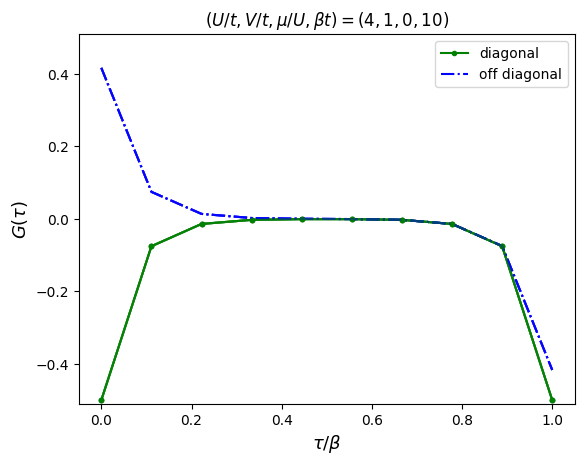

In [26]:
taus = np.linspace(0,1,num=G.shape[0])
for key,value in G_non_zero.items():
    if key[0]==key[1]:
        #continue
        plt.plot(taus,np.real(value),'.-',c='g',alpha=0.2)
    if key[0]!=key[1]:
        #continue
        plt.plot(taus,np.real(value),'-.',c='b',alpha=0.2)
plt.plot(taus,1+0*taus,'.-',c='g',label='diagonal')
plt.plot(taus,1+0*taus,'-.',c='b',label='off diagonal')
#plt.xticks([0,5,10],[0,0.5,1.0])
plt.xlabel('$\\tau/\\beta$',fontsize=13)
plt.ylabel('$G(\\tau)$',fontsize=13)
#plt.xlim([-0.1,2])
plt.ylim([-0.51,0.51])
plt.title('$(U/t,V/t,\\mu/U,\\beta t)=(4,1,0,10)$')
plt.legend()
#plt.savefig('L_2_square_half_filling.svg')